# 04 — The learned hedging policy

**What you are looking at:** the project's centerpiece. A small feedforward
network (4 inputs → two hidden layers of 32 → position in [0,1]) was trained
by differentiating *directly through the simulated P&L* — the simulator is a
chain of elementary operations, so calculus can ask how each weight should
change to make the worst 5% of outcomes less bad. No reinforcement-learning
machinery was needed, and the objective (mean loss + CVaR95 of loss) is the
exact objective the classical baselines were calibrated on.

This notebook trains **nothing**. It loads the committed weights from
`results/weights/`, re-evaluates them on the frozen TEST paths with the same
engine that scored the baselines, and *asserts* every published number. Five
training seeds per cost level; published numbers are across-seed means —
no cherry-picking.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

import deep_hedging
from deep_hedging.claims import verify_claims
from deep_hedging.evaluate import (
    CANONICAL, CANONICAL_GBM, cvar, generate_path_set, path_set_fingerprint, simulate_hedge,
)
from deep_hedging.policy import HedgePolicy, PolicyStrategy, load_policy
from deep_hedging.train import COST_LEVELS_BPS, TRAIN_SEEDS, weight_path
from deep_hedging.pricing import bs_delta

ROOT = Path(deep_hedging.__file__).resolve().parents[2]
RESULTS = ROOT / "results"
lp = json.loads((RESULTS / "learned_policy_results.json").read_text())
table = json.loads((RESULTS / "baseline_table.json").read_text())
print(f"loaded results for cost levels {sorted(lp['per_cost'])} x seeds {lp['config']['seeds']}")

loaded results for cost levels ['20.0', '5.0', '50.0'] x seeds [0, 1, 2, 3, 4]


## Training curves

**What you are looking at:** the objective on the VAL set after each training
epoch, per seed (from the weight sidecars — the committed record of each
run). Training used only TRAIN paths; VAL only decided when to stop. The
dashed line is the calibrated Whalley-Wilmott objective at that cost level —
the bar the policy had to clear. Curves flattening below the line = learning
worked; five seeds landing close together = the result is not a lucky seed.

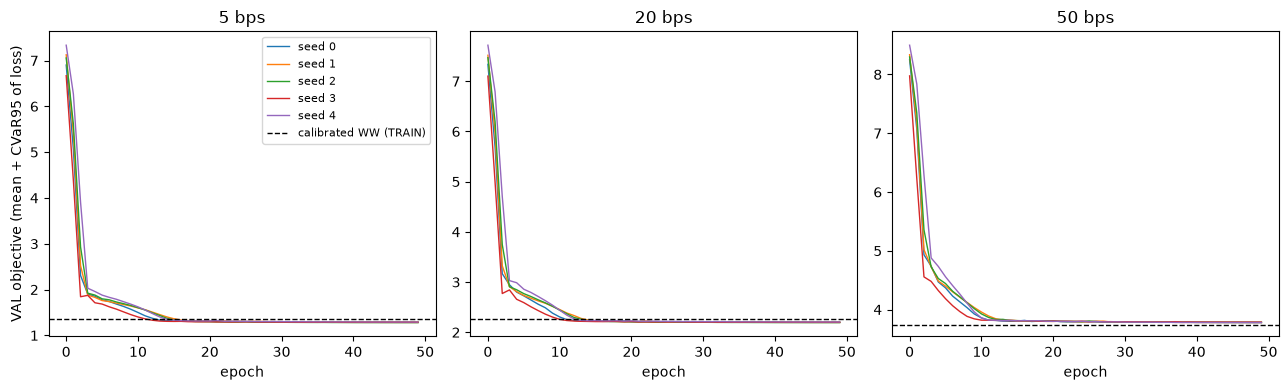

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
calib = json.loads((RESULTS / "baseline_calibration.json").read_text())
for ax, cost in zip(axes, COST_LEVELS_BPS):
    for seed in TRAIN_SEEDS:
        sidecar = json.loads(Path(f"{weight_path(cost, seed)}.json").read_text())
        ax.plot(sidecar["val_curve"], lw=1, label=f"seed {seed}")
    ww_j = calib["per_cost_level"][str(cost)]["whalley_wilmott"]["objective"]
    ax.axhline(ww_j, color="k", ls="--", lw=1, label="calibrated WW (TRAIN)")
    ax.set_title(f"{cost:g} bps"); ax.set_xlabel("epoch")
axes[0].set_ylabel("VAL objective (mean + CVaR95 of loss)")
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Reproducing the published numbers from committed weights

**What you are looking at:** the volunteer guarantee, exercised live. Every
committed policy is loaded on CPU and re-scored on the frozen TEST set (this
is a sign-off notebook, hence `final=True`); the recomputed CVaR95 and
turnover must match `learned_policy_results.json` to 1e-6 per seed. Takes a
couple of minutes for 15 policies x 100,000 paths.

In [3]:
test_paths = generate_path_set("TEST", final=True)
assert path_set_fingerprint(test_paths) == lp["config"]["path_set_sha256"]
common = dict(strike=CANONICAL["strike"], horizon=CANONICAL["horizon"], sigma=CANONICAL_GBM.sigma)

recomputed = {}
for cost in COST_LEVELS_BPS:
    losses_by_seed = []
    for row in lp["per_cost"][str(cost)]["per_seed"]:
        policy, _ = load_policy(weight_path(cost, row["seed"]))
        res = simulate_hedge(test_paths, strategy=PolicyStrategy(policy, sigma=CANONICAL_GBM.sigma),
                             cost_rate=cost / 10_000.0, **common)
        assert abs(cvar(-res.pnl, 0.95) - row["cvar95"]) < 1e-6
        assert abs(cvar(-res.pnl, 0.99) - row["cvar99"]) < 1e-6
        assert abs(res.turnover.mean() - row["turnover"]) < 1e-6
        losses_by_seed.append(-res.pnl)
    recomputed[cost] = losses_by_seed
    print(f"{cost:g} bps: all {len(losses_by_seed)} seeds reproduce stored metrics to 1e-6")

5 bps: all 5 seeds reproduce stored metrics to 1e-6


20 bps: all 5 seeds reproduce stored metrics to 1e-6


50 bps: all 5 seeds reproduce stored metrics to 1e-6


## Scoreboard: learned policy vs. calibrated classical baselines

**What you are looking at:** across-seed mean ± std for the learned policy
(error bars) against the frozen baseline table, on CVaR(95%) and turnover.
The learned policy is judged by the same engine, same paths, same cost
levels. Watch both panels together: matching WW's tail risk while trading
less, or beating it while trading the same, is what H1 asks for.

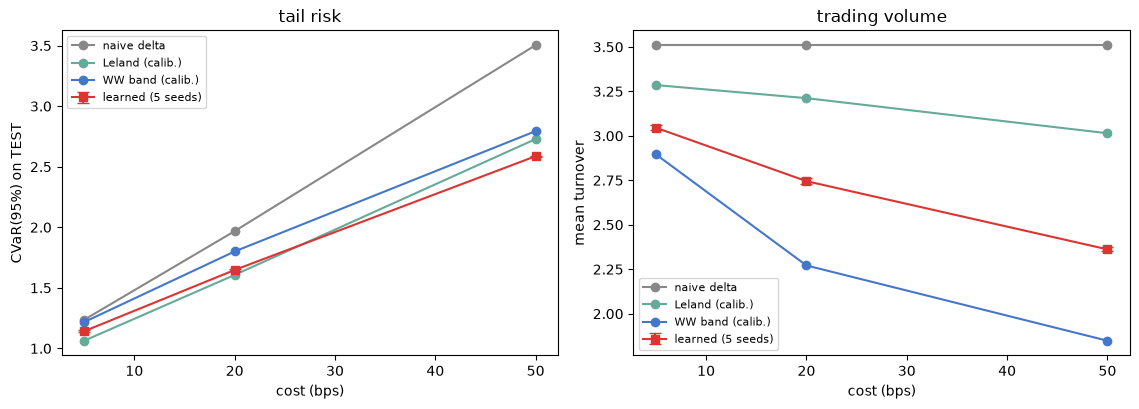

   5 bps: learned CVaR95 1.1418 ± 0.0066 | WW 1.2177 | learned turnover 3.045 | WW 2.896
  20 bps: learned CVaR95 1.6477 ± 0.0076 | WW 1.8006 | learned turnover 2.745 | WW 2.271
  50 bps: learned CVaR95 2.5870 ± 0.0057 | WW 2.7940 | learned turnover 2.362 | WW 1.848


In [4]:
by_baseline = {(r["cost_bps"], r["strategy"]): r for r in table["rows"]}
costs = list(COST_LEVELS_BPS)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))
for strat, label, color in [("bs_delta", "naive delta", "#888"),
                            ("leland", "Leland (calib.)", "#6a9"),
                            ("whalley_wilmott", "WW band (calib.)", "#47c")]:
    ax1.plot(costs, [by_baseline[(c, strat)]["cvar95"] for c in costs], "o-", color=color, label=label)
    ax2.plot(costs, [by_baseline[(c, strat)]["turnover"] for c in costs], "o-", color=color, label=label)
means = [lp["per_cost"][str(c)]["across_seeds"]["cvar95"]["mean"] for c in costs]
stds = [lp["per_cost"][str(c)]["across_seeds"]["cvar95"]["std"] for c in costs]
ax1.errorbar(costs, means, yerr=stds, fmt="s-", color="#d33", capsize=4, label="learned (5 seeds)")
t_means = [lp["per_cost"][str(c)]["across_seeds"]["turnover"]["mean"] for c in costs]
t_stds = [lp["per_cost"][str(c)]["across_seeds"]["turnover"]["std"] for c in costs]
ax2.errorbar(costs, t_means, yerr=t_stds, fmt="s-", color="#d33", capsize=4, label="learned (5 seeds)")
ax1.set_xlabel("cost (bps)"); ax1.set_ylabel("CVaR(95%) on TEST"); ax1.set_title("tail risk")
ax2.set_xlabel("cost (bps)"); ax2.set_ylabel("mean turnover"); ax2.set_title("trading volume")
ax1.legend(fontsize=8); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

for c in costs:
    e = lp["per_cost"][str(c)]
    print(f"{c:>4g} bps: learned CVaR95 {e['across_seeds']['cvar95']['mean']:.4f} ± {e['across_seeds']['cvar95']['std']:.4f} "
          f"| WW {e['ww_baseline']['cvar95']:.4f} | learned turnover {e['across_seeds']['turnover']['mean']:.3f} "
          f"| WW {e['ww_baseline']['turnover']:.3f}")

## The H1 verdict

**What you are looking at:** the pre-registered hypothesis, settled. H1 says:
at 20 bps the learned policy reduces CVaR(95%) vs. calibrated Whalley-Wilmott
at equal or lower turnover. The test is paired — each bootstrap resample
draws the same path indices for both strategies, so market luck cancels and
only the strategy difference remains. Supported requires the 95% CI of the
CVaR difference to sit entirely below zero AND the turnover condition to
hold. Whatever the outcome, it is recorded in HYPOTHESES.md — a negative
would be published, not reworked.

In [5]:
h1 = lp["h1"]
print(json.dumps(h1, indent=2))
lo, hi = h1["cvar_diff_ci95"]
assert (h1["verdict"] == "supported") == (hi < 0.0 and h1["turnover_condition_met"])

# recompute the paired bootstrap from the recomputed losses (independent check)
rng = np.random.default_rng(lp["config"]["boot_seed"])
ww_gamma = lp["per_cost"]["20.0"]["ww_baseline"]["risk_aversion"]
from deep_hedging.baselines import make_whalley_wilmott_strategy
ww_losses = -simulate_hedge(test_paths, strategy=make_whalley_wilmott_strategy(ww_gamma),
                            cost_rate=20.0 / 10_000.0, **common).pnl
n = ww_losses.size
diffs = np.empty(lp["config"]["n_boot"])
for b in range(lp["config"]["n_boot"]):
    idx = rng.integers(0, n, n)
    diffs[b] = np.mean([cvar(l[idx]) for l in recomputed[20.0]]) - cvar(ww_losses[idx])
ci = np.quantile(diffs, [0.025, 0.975])
print(f"recomputed CI [{ci[0]:.4f}, {ci[1]:.4f}] vs stored [{lo:.4f}, {hi:.4f}]")
assert abs(ci[0] - lo) < 1e-9 and abs(ci[1] - hi) < 1e-9

{
  "cvar_diff_ci95": [
    -0.16443763801179534,
    -0.14071739121956814
  ],
  "cvar_diff_mean": -0.15344279499487645,
  "policy_turnover_mean": 2.7452298958989623,
  "statement": "at 20 bps the learned policy reduces CVaR95 vs calibrated WW at equal or lower turnover",
  "turnover_condition_met": false,
  "verdict": "not supported",
  "ww_turnover": 2.271233603460236
}


recomputed CI [-0.1644, -0.1407] vs stored [-0.1644, -0.1407]


## What did the network actually learn?

**What you are looking at:** the learned position as a function of the spot
price, drawn for three different *current holdings* (0.2, 0.5, 0.8) at
mid-life, 20 bps, seed 0 — against the Black-Scholes delta. If the network
learned band-like behavior, the three curves separate: where you already
hold 0.2 it stays lower, where you hold 0.8 it stays higher — inertia around
the current holding, i.e. an implicit no-trade region. (Stage 5 quantifies
this properly; this plot is the teaser.)

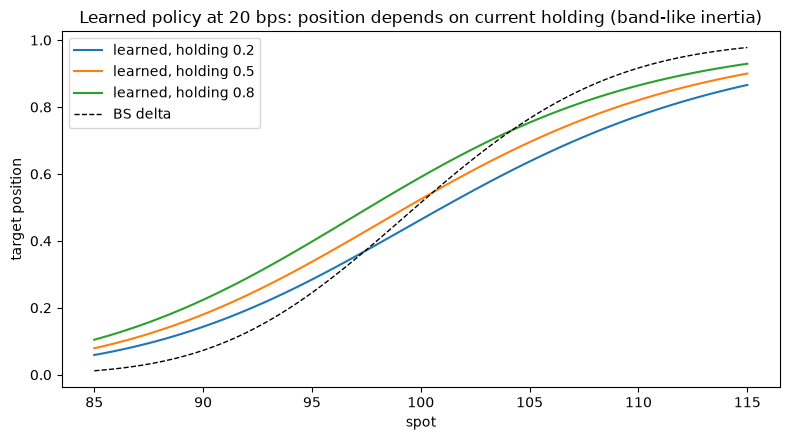

In [6]:
policy, _ = load_policy(weight_path(20.0, 0))
spots = np.linspace(85, 115, 121)
tau = 0.125
from deep_hedging.policy import build_features
fig, ax = plt.subplots(figsize=(8, 4.5))
for h in (0.2, 0.5, 0.8):
    feats = build_features(np.log(spots / CANONICAL["strike"]),
                           np.full_like(spots, tau / CANONICAL["horizon"]),
                           np.full_like(spots, h),
                           np.zeros_like(spots))
    with torch.no_grad():
        pos = policy(torch.from_numpy(feats)).numpy()
    ax.plot(spots, pos, label=f"learned, holding {h}")
ax.plot(spots, bs_delta(spots, CANONICAL["strike"], tau, CANONICAL_GBM.sigma), "k--", lw=1, label="BS delta")
ax.set_xlabel("spot"); ax.set_ylabel("target position")
ax.set_title("Learned policy at 20 bps: position depends on current holding (band-like inertia)")
ax.legend(); plt.tight_layout(); plt.show()

## Frozen-claims check

Every headline number above is registered in `CLAIMS.md`; `verify_claims`
fails on any mismatch, any registered-but-not-shown number, and any
shown-but-not-registered number.

In [7]:
computed = {
    f"LP{c:g}-CVAR95-MEAN": lp["per_cost"][str(c)]["across_seeds"]["cvar95"]["mean"]
    for c in COST_LEVELS_BPS
} | {
    "LP20-TURNOVER-MEAN": lp["per_cost"]["20.0"]["across_seeds"]["turnover"]["mean"],
    "H1-CVAR-DIFF-MEAN": h1["cvar_diff_mean"],
}
print(verify_claims("04_learned_policy", computed))
print("04_learned_policy: all assertions passed")

verified 5 claims for 04_learned_policy (atol=0.0001)
04_learned_policy: all assertions passed
